# Add to the path

In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

# Import Libraries

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

import torch
from torch import nn
from torch import optim
from einops import rearrange
from sklearn.model_selection import train_test_split

import tltorch
from Utils.Reshape import reshape
from Utils.Num_parameter import count_parameters

# Synthetic Data

device is set to : cuda


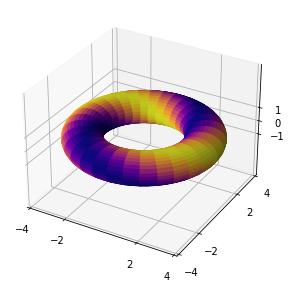

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device is set to : {device}')

def generate_gaussian_tensor(n_samples, size):
    mean = 0
    variance = 5
    std_dev = torch.sqrt(torch.tensor(variance))
    tensor = np.random.normal(mean, std_dev, (n_samples, size, size))
    tensor = torch.from_numpy(tensor).float()

    (theta, phi) = np.meshgrid(np.linspace(0, 2 * np.pi, size),
                           np.linspace(0, 2 * np.pi, size))
    
    Weight = torch.zeros((3, size, size))
    Weight[0,:,:] = torch.from_numpy((3 + np.cos(phi)) * np.cos(theta)).float()
    Weight[1,:,:] = torch.from_numpy((3 + np.cos(phi)) * np.sin(theta)).float()
    Weight[2,:,:] = torch.from_numpy(np.sin(phi)).float()

    output  = torch.einsum('abc, ocb->ao', tensor, Weight)


    mean = 0
    variance = 1
    std_dev = torch.sqrt(torch.tensor(variance))
    noise = np.random.normal(mean, std_dev, (n_samples, size, size))
    noise = torch.from_numpy(noise).float()

    return tensor.to(device), output.to(device), Weight.to(device), (tensor+noise).to(device)

n_samples = 1000
size = 64

samples, y, W, x = generate_gaussian_tensor(n_samples, size)


(theta, phi) = np.meshgrid(np.linspace(0, 2 * np.pi, size),
                           np.linspace(0, 2 * np.pi, size))
def fun(t, f): return (np.cos(f + 2 * t) + 1) / 2

fig = plt.figure(num=1, clear=True)
ax = fig.add_subplot(1, 1, 1, projection='3d')

dplot = ax.plot_surface(W[0,:,:].cpu(), W[1,:,:].cpu(), W[2,:,:].cpu(), facecolors=cm.get_cmap('plasma')(fun(theta, phi)))
ax.set(xlim = [-4, 4],
       ylim = [-4, 4],
       zlim = [-4, 4],
       xticks = [-4, -2, 2, 4],
       yticks = [-4, -2, 2, 4],
       zticks = [-1, 0, 1])

fig.tight_layout()
plt.show()

# Basic Linear Model

Epoch [1/10000], Loss: 68583.5234375
Epoch [101/10000], Loss: 56431.59375
Epoch [201/10000], Loss: 46535.48828125
Epoch [301/10000], Loss: 38404.00390625
Epoch [401/10000], Loss: 31673.775390625
Epoch [501/10000], Loss: 26077.396484375
Epoch [601/10000], Loss: 21411.583984375
Epoch [701/10000], Loss: 17517.98828125
Epoch [801/10000], Loss: 14270.6748046875
Epoch [901/10000], Loss: 11567.4775390625
Epoch [1001/10000], Loss: 9324.0009765625
Epoch [1101/10000], Loss: 7469.427734375
Epoch [1201/10000], Loss: 5943.6298828125
Epoch [1301/10000], Loss: 4695.1826171875
Epoch [1401/10000], Loss: 3679.92333984375
Epoch [1501/10000], Loss: 2859.884033203125
Epoch [1601/10000], Loss: 2202.447021484375
Epoch [1701/10000], Loss: 1679.650146484375
Epoch [1801/10000], Loss: 1267.595703125
Epoch [1901/10000], Loss: 945.9469604492188
Epoch [2001/10000], Loss: 697.4847412109375
Epoch [2101/10000], Loss: 507.7199401855469
Epoch [2201/10000], Loss: 364.5497131347656
Epoch [2301/10000], Loss: 257.9496765136

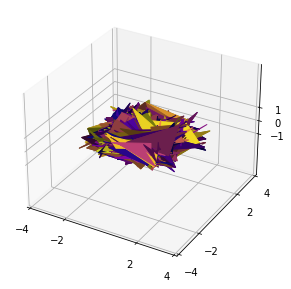

In [10]:
class simple_linear(nn.Module):
    def __init__(self):
        super(simple_linear, self).__init__()
        self.fc = nn.Linear(in_features= size*size, out_features=3, bias=False)
    def forward(self, x):
        x = x.reshape(-1,size*size)
        return self.fc(x)
    
model = simple_linear().to(device)

# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)

    loss.backward()
    optimizer.step()
    
    if epoch%100 ==0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

W_fc = model.fc.weight.reshape(-1,size,size)

fig = plt.figure(num=1, clear=True)
ax = fig.add_subplot(1, 1, 1, projection='3d')

dplot = ax.plot_surface(W_fc[0,:,:].detach().cpu(), W_fc[1,:,:].detach().cpu(), W_fc[2,:,:].detach().cpu(), facecolors=cm.get_cmap('plasma')(fun(theta, phi)))
ax.set(xlim = [-4, 4],
       ylim = [-4, 4],
       zlim = [-4, 4],
       xticks = [-4, -2, 2, 4],
       yticks = [-4, -2, 2, 4],
       zticks = [-1, 0, 1])

fig.tight_layout()
plt.show()

# Basic TRL Model

Epoch [1/10000], Loss: 102381.7890625
Epoch [101/10000], Loss: 23866.234375
Epoch [201/10000], Loss: 5136.16455078125
Epoch [301/10000], Loss: 2830.913330078125
Epoch [401/10000], Loss: 1457.9150390625
Epoch [501/10000], Loss: 631.7448120117188
Epoch [601/10000], Loss: 286.4536437988281
Epoch [701/10000], Loss: 139.8525390625
Epoch [801/10000], Loss: 71.3134765625
Epoch [901/10000], Loss: 37.13262939453125
Epoch [1001/10000], Loss: 19.399227142333984
Epoch [1101/10000], Loss: 10.038990020751953
Epoch [1201/10000], Loss: 5.103347301483154
Epoch [1301/10000], Loss: 2.5353734493255615
Epoch [1401/10000], Loss: 1.2269647121429443
Epoch [1501/10000], Loss: 0.5770761370658875
Epoch [1601/10000], Loss: 0.2632828950881958
Epoch [1701/10000], Loss: 0.1163194328546524
Epoch [1801/10000], Loss: 0.04967749863862991
Epoch [1901/10000], Loss: 0.020472368225455284
Epoch [2001/10000], Loss: 0.008126267232000828
Epoch [2101/10000], Loss: 0.0031006077770143747
Epoch [2201/10000], Loss: 0.001135114813223

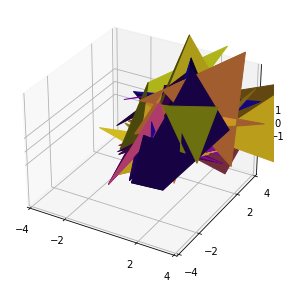

In [11]:
class simple_trl(nn.Module):
    def __init__(self):
        super(simple_trl, self).__init__()
        self.trl = tltorch.TRL(input_shape=(64,64), rank=(64,64,3), output_shape=(3), bias=False, factorization='tucker')
    def forward(self, x):
        return self.trl(x)
    
model = simple_trl().to(device)


# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)

    loss.backward()
    optimizer.step()
    
    if epoch%100 ==0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

W_trl = model.trl.weight.to_tensor()

fig = plt.figure(num=1, clear=True)
ax = fig.add_subplot(1, 1, 1, projection='3d')

dplot = ax.plot_surface(W_trl[0,:,:].detach().cpu(), W_trl[1,:,:].detach().cpu(), W_trl[2,:,:].detach().cpu(), facecolors=cm.get_cmap('plasma')(fun(theta, phi)))
ax.set(xlim = [-4, 4],
       ylim = [-4, 4],
       zlim = [-4, 4],
       xticks = [-4, -2, 2, 4],
       yticks = [-4, -2, 2, 4],
       zticks = [-1, 0, 1])

fig.tight_layout()
plt.show()

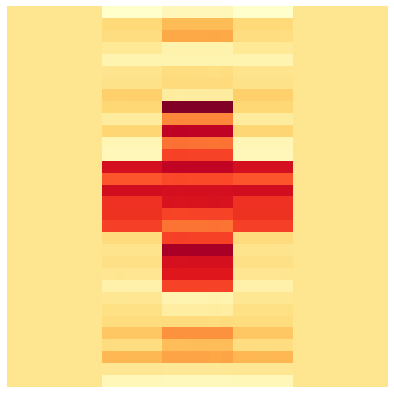

This Model has : 345 parameters
RMSE of Train : 1.4935900901847765
RMSE of Test  : 2.0374921693241848


In [8]:
class simple_trl(nn.Module):
    def __init__(self):
        super(simple_trl, self).__init__()
        self.trl = tltorch.TRL(input_shape=(size), rank=(5,5), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        return self.trl(x)
    
model = simple_trl().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()
    
W_trl = model.trl.weight.to_tensor()

fig = plt.figure(figsize=(10,7))
plt.imshow(W_trl.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
plt.show()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')


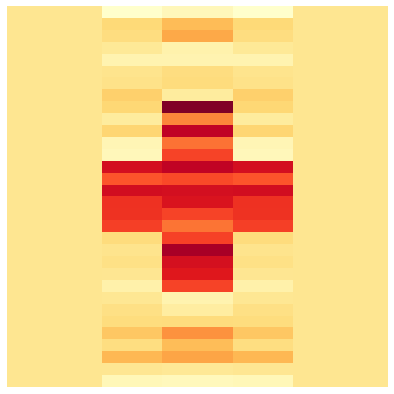

This Model has : 740 parameters
RMSE of Train : 1.493578118047832
RMSE of Test  : 2.0375168594879782


In [9]:
class simple_trl(nn.Module):
    def __init__(self):
        super(simple_trl, self).__init__()
        self.trl = tltorch.TRL(input_shape=(size), rank=(10,10), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        return self.trl(x)
    
model = simple_trl().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()
    
W_trl = model.trl.weight.to_tensor()

fig = plt.figure(figsize=(10,7))
plt.imshow(W_trl.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
plt.show()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')


# Basic Attached Model

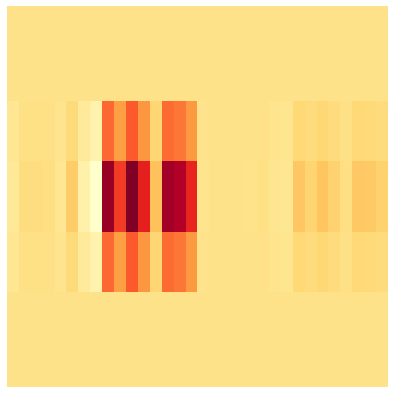

This Model has : 58 parameters
RMSE of Train : 2.9441710671086865
RMSE of Test  : 2.6699074979895925


In [10]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[1,1,2], map_type=1, device=device)
        self.trl = tltorch.TRL(input_shape=(1,1,2,1,1,size//2), rank=(1,1,2,1,1,1,1), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1).unsqueeze(dim=2)
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    
    loss.backward()
    optimizer.step()

W_attached = rearrange(model.trl.weight.to_tensor(), 'a b c d e f g -> g (c f) (b e) (a d)').squeeze()

fig = plt.figure(figsize=(10,7))
plt.imshow(W_attached.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
plt.show()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')


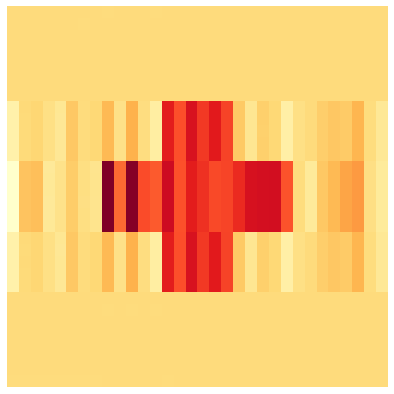

This Model has : 298 parameters
RMSE of Train : 1.5598542510929378
RMSE of Test  : 1.3274077778911224


In [11]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[1,1,2], map_type=1, device=device)
        self.trl = tltorch.TRL(input_shape=(1,1,2,1,1,size//2), rank=(1,1,2,1,1,5,5), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1).unsqueeze(dim=2)
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    
    loss.backward()
    optimizer.step()

W_attached = rearrange(model.trl.weight.to_tensor(), 'a b c d e f g -> g (c f) (b e) (a d)').squeeze()

fig = plt.figure(figsize=(10,7))
plt.imshow(W_attached.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
plt.show()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')


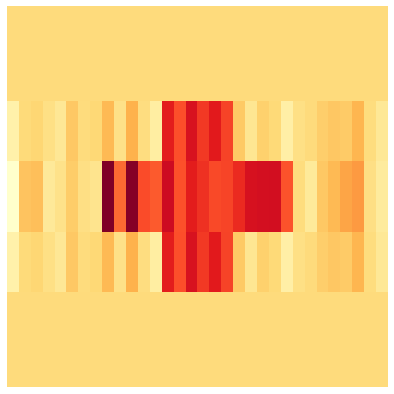

This Model has : 688 parameters
RMSE of Train : 1.5598414119170643
RMSE of Test  : 1.327419766948706


In [22]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[1,1,2], map_type=1, device=device)
        self.trl = tltorch.TRL(input_shape=(1,1,2,1,1,size//2), rank=(1,1,2,1,1,10,10), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1).unsqueeze(dim=2)
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    
    loss.backward()
    optimizer.step()

W_attached = rearrange(model.trl.weight.to_tensor(), 'a b c d e f g -> g (c f) (b e) (a d)').squeeze()

fig = plt.figure(figsize=(10,7))
plt.imshow(W_attached.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
plt.show()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')


# Basic Compressed Model

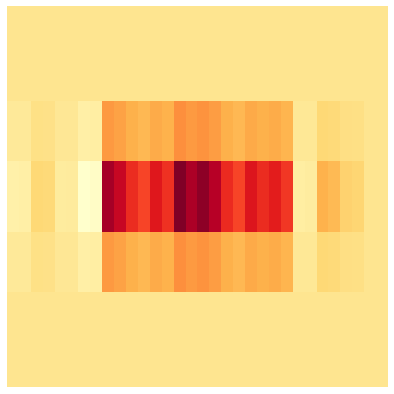

This Model has : 58 parameters
RMSE of Train : 2.3499264522974492
RMSE of Test  : 2.068637270895702


In [15]:
class simple_compressed(nn.Module):
    def __init__(self):
        super(simple_compressed, self).__init__()
        self.reshape = reshape(split=[1,1,2], map_type=2, device=device)
        self.trl = tltorch.TRL(input_shape=(1,1,2,1,1,size//2), rank=(1,1,2,1,1,1,1), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1).unsqueeze(dim=2)
        return self.trl(self.reshape(x))
    
model = simple_compressed().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    
    loss.backward()
    optimizer.step()

W_compressed = rearrange(model.trl.weight.to_tensor(), 'a b c d e f g -> g (f c) (e b) (d a)').squeeze()

fig = plt.figure(figsize=(10,7))
plt.imshow(W_compressed.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
plt.show()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')


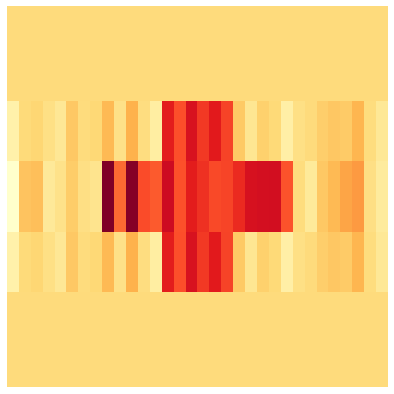

This Model has : 298 parameters
RMSE of Train : 1.559867319431283
RMSE of Test  : 1.3272975363497064


In [16]:
class simple_compressed(nn.Module):
    def __init__(self):
        super(simple_compressed, self).__init__()
        self.reshape = reshape(split=[1,1,2], map_type=2, device=device)
        self.trl = tltorch.TRL(input_shape=(1,1,2,1,1,size//2), rank=(1,1,2,1,1,5,5), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1).unsqueeze(dim=2)
        return self.trl(self.reshape(x))
    
model = simple_compressed().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    
    loss.backward()
    optimizer.step()

W_compressed = rearrange(model.trl.weight.to_tensor(), 'a b c d e f g -> g (f c) (e b) (d a)').squeeze()

fig = plt.figure(figsize=(10,7))
plt.imshow(W_compressed.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
plt.show()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')


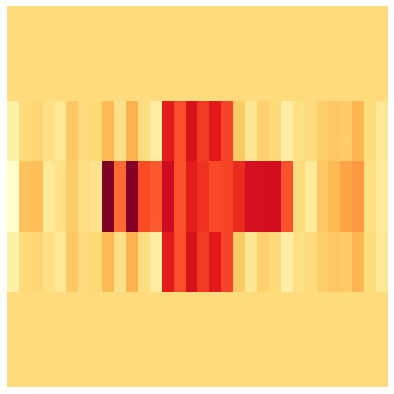

This Model has : 688 parameters
RMSE of Train : 1.559867701544792
RMSE of Test  : 1.327297850697057


In [17]:
class simple_compressed(nn.Module):
    def __init__(self):
        super(simple_compressed, self).__init__()
        self.reshape = reshape(split=[1,1,2], map_type=2, device=device)
        self.trl = tltorch.TRL(input_shape=(1,1,2,1,1,size//2), rank=(1,1,2,1,1,10,10), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1).unsqueeze(dim=2)
        return self.trl(self.reshape(x))
    
model = simple_compressed().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    
    loss.backward()
    optimizer.step()

W_compressed = rearrange(model.trl.weight.to_tensor(), 'a b c d e f g -> g (f c) (e b) (d a)').squeeze()

fig = plt.figure(figsize=(10,7))
plt.imshow(W_compressed.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
plt.show()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')
